# Capstone Project: French Railway Delays

**Overview**: In this capston project, the key research question to be answered is - how can a railway operator improve the reliability of its railway system? 

**Data Source**: https://www.kaggle.com/datasets/gatandubuc/public-transport-traffic-data-in-france?select=Regularities_by_liaisons_Trains_France.csv

This dataset contains all the point-to-point delay / on-time data for the France High Speed Rail network (TSV), accompanied by the causes of the delays if any. 

**Expected Results**: The analysis is expected to reveal the "what, where, when, why" factors contributing to train delays, and provide simple predictive tools to forecast and mitigate future disruptions. 

**Why it matters**: Public transport commutes affects millions of people daily and can be disruptive when then system is not reliable. Doing a detailed analysis of the reasons for potential faults can advise the railway operator to pre-emptively take interventions either in terms of operations (e.g. on rainy days, have additional surveillance), or maintenance (e.g. check trains more thoroughly after a rainy day), ultimately improving the reliability of the system that serves so many on a daily basis. 



## A. Business Understanding

##### _Step 1: Import Relevant Libraries_

In [195]:
# Import Libraries
# The basics 
import numpy as np
import pandas as pd 

# Importing  tools for visualization
import seaborn as sns
import plotly.express as px 
import matplotlib.pyplot as plt

# Import tools for data preprocessing and pipelines 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel 

# Import tools for model creation 
from sklearn.linear_model import LinearRegression,Lasso,Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

# Import evaluation metric libraries
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score


# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##### _Step 2: Load the Data and Take a Look_

In [67]:
df = pd.read_csv('data/traindelays.csv')
df.head()

,Year,Month,Departure station,Arrival station,Average travel time (min),Number of expected circulations,Number of cancelled trains,Number of late trains at departure,Average delay of late departing trains (min),Average delay of all departing trains (min),...,Average train delay > 15min,Number of late trains > 30min,Number of late trains > 60min,Period,Delay due to external causes,Delay due to railway infrastructure,Delay due to traffic management,Delay due to rolling stock,Delay due to station management and reuse of material,Delay due to travellers taken into account
0,2019,7.0,ANGOULEME,PARIS MONTPARNASSE,131.914980,247.0,0.0,191.0,3.576353,2.678273,...,32.965873,7.0,2.0,2019-07,25.000000,15.000000,27.500000,12.500000,2.500000,17.500000
1,2019,7.0,PARIS MONTPARNASSE,LA ROCHELLE VILLE,175.611570,242.0,0.0,178.0,9.780805,7.033609,...,32.057143,14.0,2.0,2019-07,20.000000,24.444444,26.666667,24.444444,0.000000,4.444444
2,2019,7.0,LE MANS,PARIS MONTPARNASSE,62.395349,435.0,5.0,391.0,3.896974,3.529341,...,42.367241,13.0,4.0,2019-07,16.176471,32.352941,26.470588,14.705882,2.941176,7.352941
3,2019,7.0,ST MALO,PARIS MONTPARNASSE,172.421053,114.0,0.0,101.0,1.950990,1.685673,...,27.620833,2.0,0.0,2019-07,15.384615,15.384615,23.076923,38.461538,0.000000,7.692308
4,2019,7.0,PARIS MONTPARNASSE,ST PIERRE DES CORPS,67.310000,404.0,4.0,284.0,8.379108,5.803125,...,37.658333,12.0,3.0,2019-07,18.461538,12.307692,40.000000,16.923077,7.692308,4.615385


#### _Step 3: Explore General Characteristics_ 

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7806 entries, 0 to 7805
Data columns (total 32 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   Year                                                                                                                 7806 non-null   int64  
 1   Month                                                                                                                7806 non-null   float64
 2   Departure station                                                                                                    7806 non-null   object 
 3   Arrival station                                                                                                      7806 non-null   object 
 4   Average trav

In [41]:
#check null values 
df.isnull().sum()

Year                                                                                                                      0
Month                                                                                                                     0
Departure station                                                                                                         0
Arrival station                                                                                                           0
Average travel time (min)                                                                                                63
Number of expected circulations                                                                                          63
Number of cancelled trains                                                                                                0
Number of late trains at departure                                                                                        0
Average 

#### _Step 4: Handle NULL Values_

In [69]:
# Remove columns with too many null values
df = df.drop(columns=['Comment (optional) delays at departure', 'Comment (optional) delays on arrival'])

In [70]:
# drop duplicate columns
df = df.drop(columns=["% trains late due to external causes (weather, obstacles, suspicious packages, malevolence, social movements, etc.)",
"% trains late due to railway infrastructure (maintenance, works)",
"% trains late due to traffic management (rail line traffic, network interactions)",
"% trains late due to rolling stock",
"% trains late due to station management and reuse of material",
"% trains late due to passenger traffic (affluence, PSH management, connections)"]) 

In [71]:
# drop rows where having a null value doesnt make sense - route may no longer be in operations
df = df.dropna(subset=["Average travel time (min)", "Number of expected circulations"])

In [72]:
# impute rows where having a null value makes sense - e.g. when #trains late is zero 
cols = ["Number of trains late on arrival", "Average delay of late arriving trains (min)", "Average train delay > 15min", "Number of late trains > 30min", "Number of late trains > 60min", "Number of late trains > 15min"]
df[cols] = df[cols].fillna(0)

In [73]:
# investigate rows for which delay due to some reason is NULL 
df[df["Delay due to external causes"].isna()]
# create a new column to indicate delay cause due to "others" / maybe there were no delays 
df['Delay due to others'] = df['Delay due to external causes'].isna().astype(int) * 100
# fill the rest of the null values with 0
df = df.fillna(0)

In [74]:
# drop rows that are less meaningful for our analysis 
# presume trains late at departure are less crucial so long as it arrived on time 
df = df.drop(columns=["Number of late trains at departure", "Average delay of late departing trains (min)", "Average delay of all departing trains (min)"])

#### _Step 5: Do Some Feature Engineering_

Create some new meaningful columns before proceeding with analysis

In [75]:
# create a liaison column for route-based analysis
df['liaison'] = df['Departure station'].astype(str) + ' - ' + df['Arrival station'].astype(str)


In [76]:
# create new features to normalise useful KPIs
df['cancellation_rate'] = df['Number of cancelled trains'] / df['Number of expected circulations']
df['lateness_rate'] = df['Number of trains late on arrival'] / df['Number of expected circulations']


In [77]:
# make sure Period is true date-time
# we retain year and month as it may be useful later
df['period'] = pd.to_datetime(df['Period'], format='%Y-%m')
# drop the Period column 
df = df.drop(columns='Period')


In [78]:
# Rename columns for easier access 
df = df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Departure station': 'departure_station',
    'Arrival station': 'arrival_station',
    'Number of expected circulations': 'expected_trains',
    'Number of cancelled trains': 'cancelled_trains',
    'Number of trains late on arrival': 'late_trains',
    'Average travel time (min)': 'avg_travel_time',
    'Average delay of late arriving trains (min)': 'avg_delay_all_late_trains',
    'Average delay of all arriving trains (min)': 'avg_delay_all_trains',
    'Average train delay > 15min': 'avg_delay_over_15min',
    'Number of late trains > 15min': 'late_trains_over_15min',
    'Number of late trains > 30min': 'late_trains_over_30min',
    'Number of late trains > 60min': 'late_trains_over_60min',
    'Delay due to external causes': 'cause_ext',
    'Delay due to railway infrastructure': 'cause_infra',
    'Delay due to traffic management': 'cause_traffic',
    'Delay due to rolling stock': 'cause_rs',
    'Delay due to station management and reuse of material': 'cause_station',
    'Delay due to travellers taken into account': 'cause_pax',
    'Delay due to others': 'cause_others',
})

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7743 entries, 0 to 7805
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   year                       7743 non-null   int64         
 1   month                      7743 non-null   float64       
 2   departure_station          7743 non-null   object        
 3   arrival_station            7743 non-null   object        
 4   avg_travel_time            7743 non-null   float64       
 5   expected_trains            7743 non-null   float64       
 6   cancelled_trains           7743 non-null   float64       
 7   late_trains                7743 non-null   float64       
 8   avg_delay_all_late_trains  7743 non-null   float64       
 9   avg_delay_all_trains       7743 non-null   float64       
 10  late_trains_over_15min     7743 non-null   float64       
 11  avg_delay_over_15min       7743 non-null   float64       
 12  late_trains

#### _Step 6: Univariate Analysis_

In [23]:
# take a look at the numerical features
df.describe()

,Year,Month,Average travel time (min),Number of expected circulations,Number of cancelled trains,Number of late trains at departure,Average delay of late departing trains (min),Average delay of all departing trains (min),Number of trains late on arrival,Average delay of late arriving trains (min),...,Number of late trains > 15min,Average train delay > 15min,Number of late trains > 30min,Number of late trains > 60min,Delay due to external causes,Delay due to railway infrastructure,Delay due to traffic management,Delay due to rolling stock,Delay due to station management and reuse of material,Delay due to travellers taken into account
count,7806.000000,7806.000000,7743.000000,7743.000000,7806.000000,7806.000000,7806.000000,7743.000000,7706.000000,7705.000000,...,7738.000000,7699.000000,7738.000000,7738.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000
mean,2017.345119,6.216372,166.759261,266.510913,7.911478,63.519088,14.744145,2.956191,36.019595,32.737533,...,24.545231,29.379555,11.055441,4.000129,26.708546,25.504166,19.195005,18.109877,6.768831,3.643517
std,1.596611,3.440601,80.737092,157.456548,20.997806,78.822324,13.373758,5.951154,29.210396,14.009948,...,20.323532,18.929319,9.921009,4.459822,16.280439,16.010052,14.880847,13.282123,7.877975,5.782651
min,2015.000000,1.000000,35.888889,1.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,...,0.000000,-118.022363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,3.000000,100.643605,163.000000,0.000000,12.000000,7.559617,1.007765,16.000000,23.809420,...,10.000000,9.177749,4.000000,1.000000,15.625000,15.000000,8.695652,9.259259,0.000000,0.000000
50%,2017.000000,6.000000,162.178808,227.000000,1.000000,33.000000,13.535727,2.014571,28.000000,30.875000,...,19.000000,32.022500,8.000000,3.000000,25.000000,23.529412,17.142857,16.129032,5.000000,1.754386
75%,2019.000000,9.000000,207.885957,352.000000,6.000000,84.000000,18.713366,3.691398,48.000000,39.124653,...,33.000000,41.313095,15.000000,6.000000,35.714286,33.333333,26.923077,25.000000,10.000000,5.555556
max,2020.000000,12.000000,786.500000,960.000000,279.000000,591.000000,316.188095,173.571429,235.000000,258.000000,...,192.000000,258.000000,91.000000,37.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [103]:
#take a look at categorical features 
cat_columns = df.select_dtypes(exclude="number").columns

cat_columns_values = []
for col in cat_columns:
    nunique = df[col].nunique()
    unique_vals = df[col].unique()
    cat_columns_values.append({
        'column': col,
        'nunique': nunique,
        'unique_values': unique_vals
    })
cat_columns_df = pd.DataFrame(cat_columns_values)
cat_columns_df 

,column,nunique,unique_values
0,departure_station,59,"[ANGOULEME, PARIS MONTPARNASSE, LE MANS, ST MA..."
1,arrival_station,59,"[PARIS MONTPARNASSE, LA ROCHELLE VILLE, ST PIE..."
2,Period,66,"[2019-07-01 00:00:00, 2018-03-01 00:00:00, 201..."
3,liaison,130,"[ANGOULEME - PARIS MONTPARNASSE, PARIS MONTPAR..."


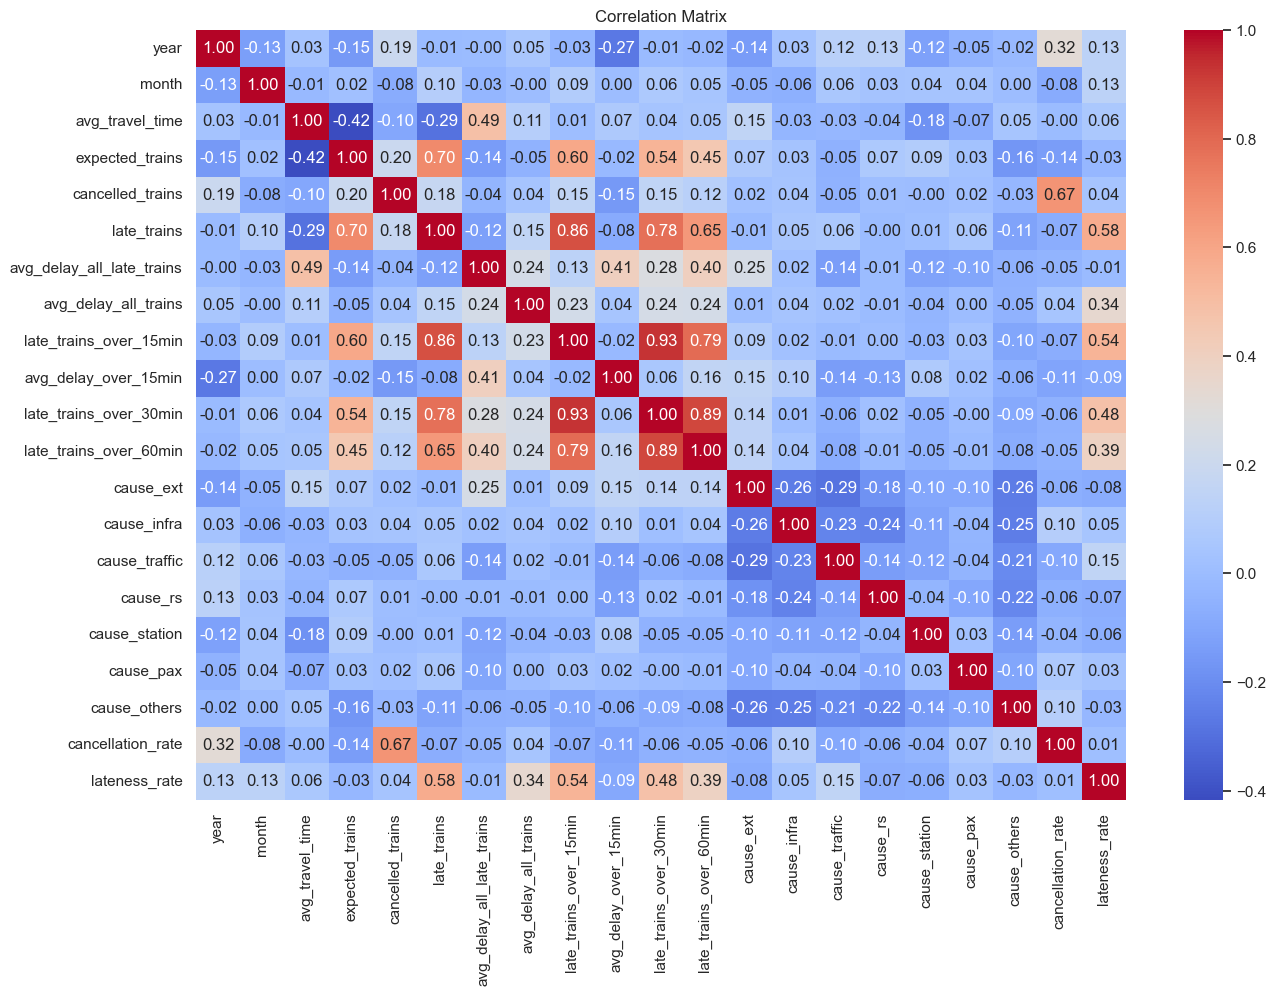

In [80]:
# Look at overall correlation matrix 
plt.figure(figsize=(15,10))
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()  

**Observation**: Looking at the `expected_trains` feature, the more trains planned for a route, the shorter its average travel time (i.e. shorter routes are more popular), and statistically, the more late trains there are, and hence the higher likelihood of trains delayed for >15 min. 

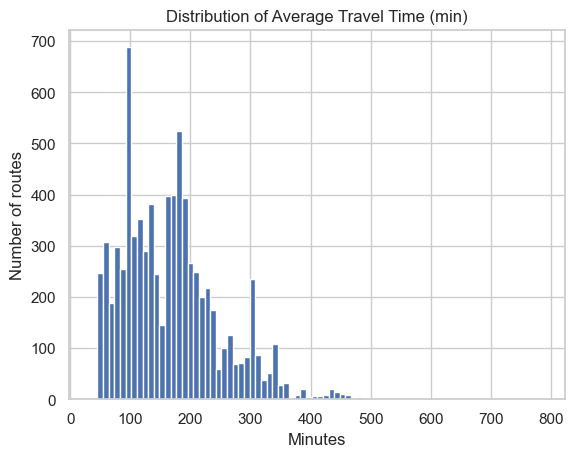

In [86]:
# take a look at the overall spread of journey types based on travel time

plt.figure()
plt.hist(df['avg_travel_time'], bins=80)
plt.title('Distribution of Average Travel Time (min)')
plt.xlabel('Minutes')
plt.ylabel('Number of routes')
plt.show()



**Observation**: One peak around the 100min mark, and another smaller peak around 180min. 

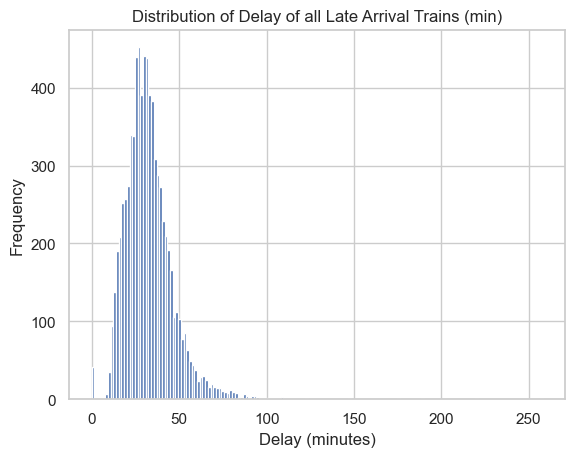

In [87]:
#Observe spread of late arriving trains  
plt.figure()
plt.hist(df["avg_delay_all_late_trains"], bins='fd')     # smarter binning
plt.title('Distribution of Delay of all Late Arrival Trains (min)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()


**Observation**: Looks almost like a normal distribution, with the peak at around 45min, and a relatively small variance. There seems to be some negative values. 

In [88]:
#investigate outliers - delays cannot be negative
df[df['avg_delay_all_late_trains'] < 0]
# drop rows where delays are negative
df = df[df['avg_delay_all_late_trains'] >= 0]
# investigate outliers - very high impact delays
df[df['avg_delay_all_late_trains']>150]
# choose to keep these for now



,year,month,departure_station,arrival_station,avg_travel_time,expected_trains,cancelled_trains,late_trains,avg_delay_all_late_trains,avg_delay_all_trains,...,cause_infra,cause_traffic,cause_rs,cause_station,cause_pax,cause_others,liaison,cancellation_rate,lateness_rate,period
1942,2016,12.0,PARIS EST,FRANCFORT,127.275000,31.0,1.0,1.0,220.0,-93.291667,...,0.0,0.0,0.0,0.0,0.0,0,PARIS EST - FRANCFORT,0.032258,0.032258,2016-12-01
2235,2016,5.0,LA ROCHELLE VILLE,PARIS MONTPARNASSE,197.271186,59.0,0.0,1.0,176.0,3.661017,...,0.0,100.0,0.0,0.0,0.0,0,LA ROCHELLE VILLE - PARIS MONTPARNASSE,0.000000,0.016949,2016-05-01
3207,2018,3.0,MARSEILLE ST CHARLES,MADRID,464.000000,31.0,1.0,1.0,190.0,4.266667,...,0.0,0.0,0.0,0.0,0.0,100,MARSEILLE ST CHARLES - MADRID,0.032258,0.032258,2018-03-01
4604,2015,10.0,NANTES,STRASBOURG,325.088889,45.0,0.0,1.0,258.0,7.022222,...,100.0,0.0,0.0,0.0,0.0,0,NANTES - STRASBOURG,0.000000,0.022222,2015-10-01


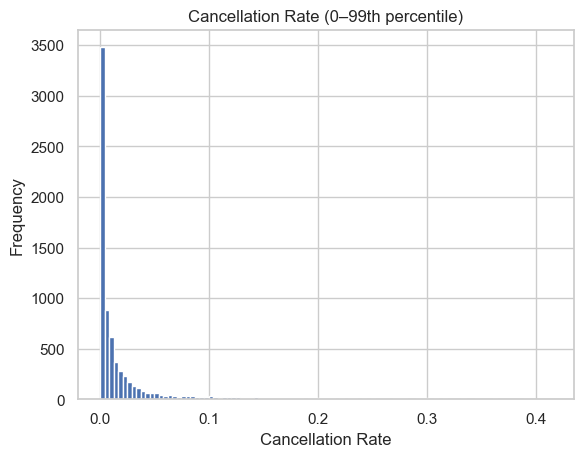

In [92]:
# investigate cancellation rates
p99 = np.percentile(df["cancellation_rate"], 99)
plt.hist(df["cancellation_rate"], bins=100, range=(0, p99))
plt.title("Cancellation Rate (0–99th percentile)")
plt.xlabel("Cancellation Rate")
plt.ylabel("Frequency")
plt.show()



**Observation**: More than half of the routes have cancellations i.e. cancellation is common, only about 37% of routes have no cancellation before. That said, most cancel less than 10% of the time. 

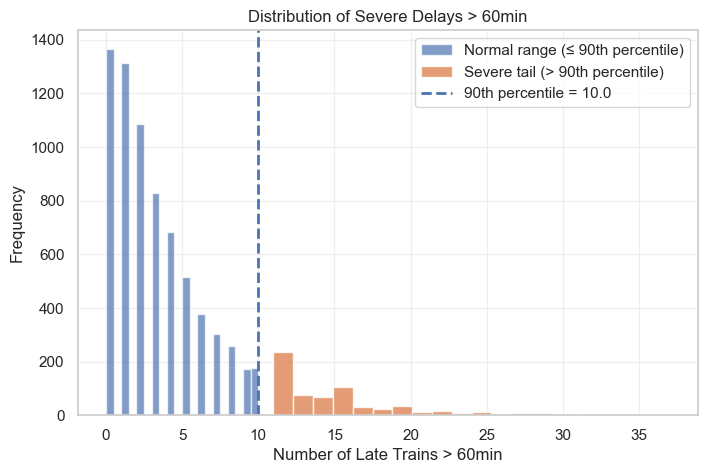

In [150]:
#Observe spread of severe delays > 60min
p90 = df["late_trains_over_60min"].quantile(0.9)

plt.figure(figsize=(8,5))

# Below 90th percentile
plt.hist(
    df[df["late_trains_over_60min"] <= p90]["late_trains_over_60min"],
    bins=20,
    alpha=0.7,
    label="Normal range (≤ 90th percentile)"
)

# Above 90th percentile
plt.hist(
    df[df["late_trains_over_60min"] > p90]["late_trains_over_60min"],
    bins=20,
    alpha=0.8,
    label="Severe tail (> 90th percentile)"
)

# Mark percentile line
plt.axvline(p90, linestyle="--", linewidth=2, label=f"90th percentile = {p90:.1f}")

plt.title("Distribution of Severe Delays > 60min")
plt.xlabel("Number of Late Trains > 60min")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



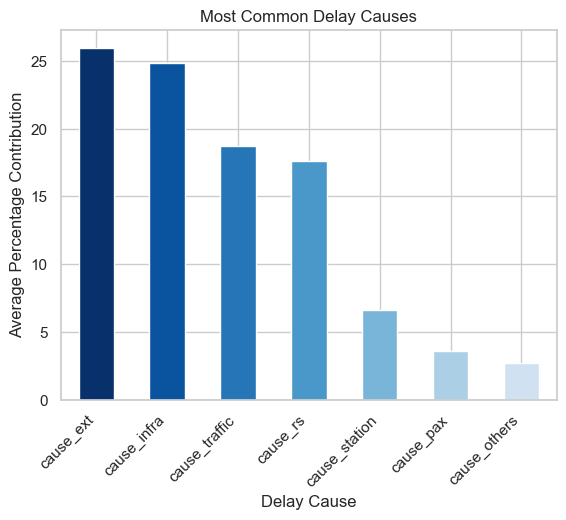

In [95]:
# Observe the most common delay causes across the network
cause_cols = ['cause_ext','cause_infra','cause_traffic','cause_rs','cause_station','cause_pax','cause_others']
cause_summary = df[cause_cols].mean()

plt.figure()
colors = plt.cm.Blues_r(np.linspace(0, 0.8, len(cause_summary)))
cause_summary.sort_values(ascending=False).plot(kind='bar', color = colors)
plt.title('Most Common Delay Causes')
plt.xlabel('Delay Cause')
plt.ylabel('Average Percentage Contribution')
plt.xticks(rotation=45, ha='right')
plt.show()


**Observations**: There hints to be maintenance and aging infrastructure issue, as well as operational issue in traffic management, for it to be the top 3 leading causes of delays. Although this would not be most accurate as we would need to see of the infra delays, how many delay mins it actually contributed to assess its actual impact (e.g. a delay can be frequent but non-disruptive if it only results in 1 min delays)

#### _Step 7: Multivariate Analysis - Seasonality_

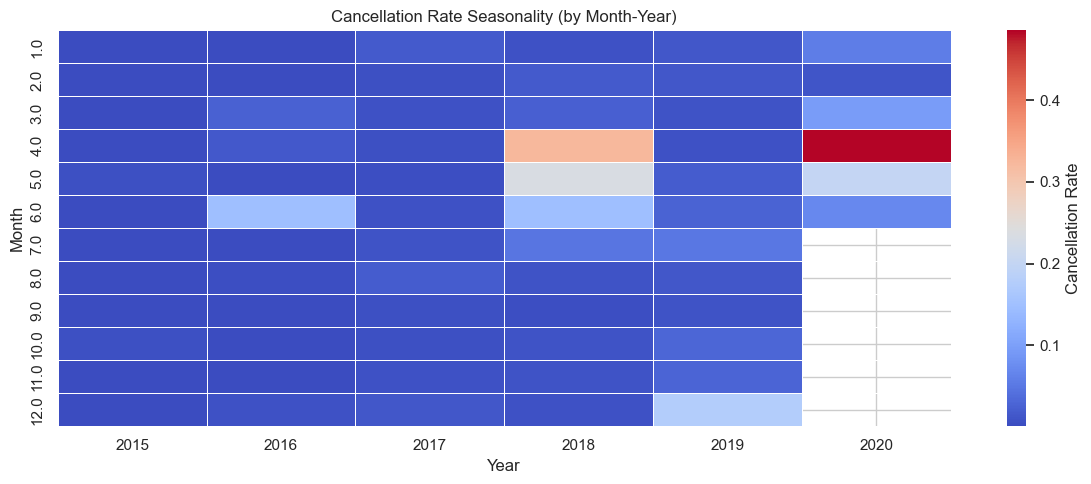

In [97]:
# Explore whether there are seasonal trends

heatmap_data = df.pivot_table(
    index="month",
    columns="year",
    values="cancellation_rate",
    aggfunc="mean"
)
 
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Cancellation Rate'}
)

plt.title("Cancellation Rate Seasonality (by Month-Year)")
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Observation**: Generally, earlier parts of the year seems worse off than second half of the year. 2020 has an exceptional anomaly. 

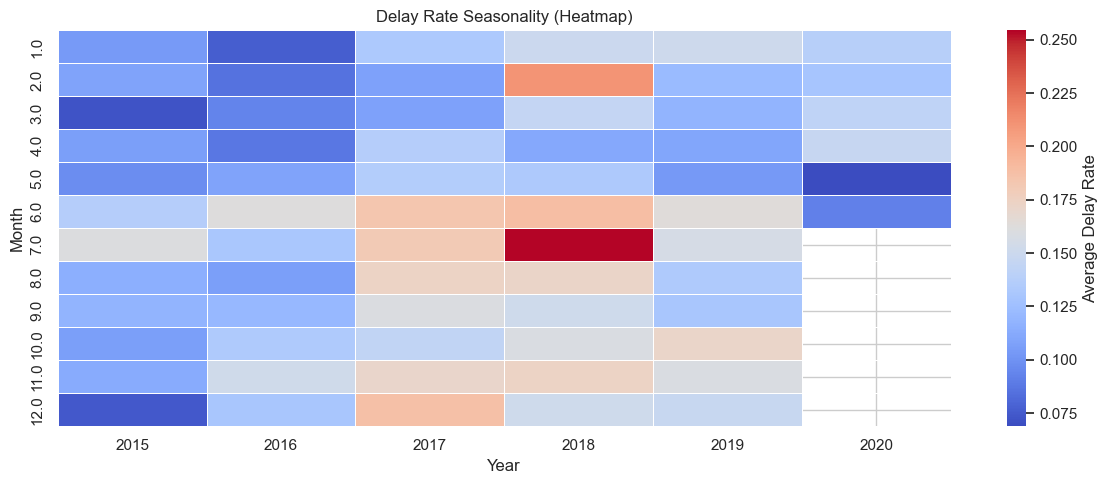

In [99]:
# Check seasonality for lateness rate
heatmap_data = df.pivot_table(
    index="month",
    columns="year",
    values="lateness_rate",
    aggfunc="mean"
)
 
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Average Delay Rate'}
)

plt.title("Delay Rate Seasonality (Heatmap)")
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


**Observation**: It appears mid of 2018 was a particular bad period, both in terms of cancellations and overall lateness rate.  

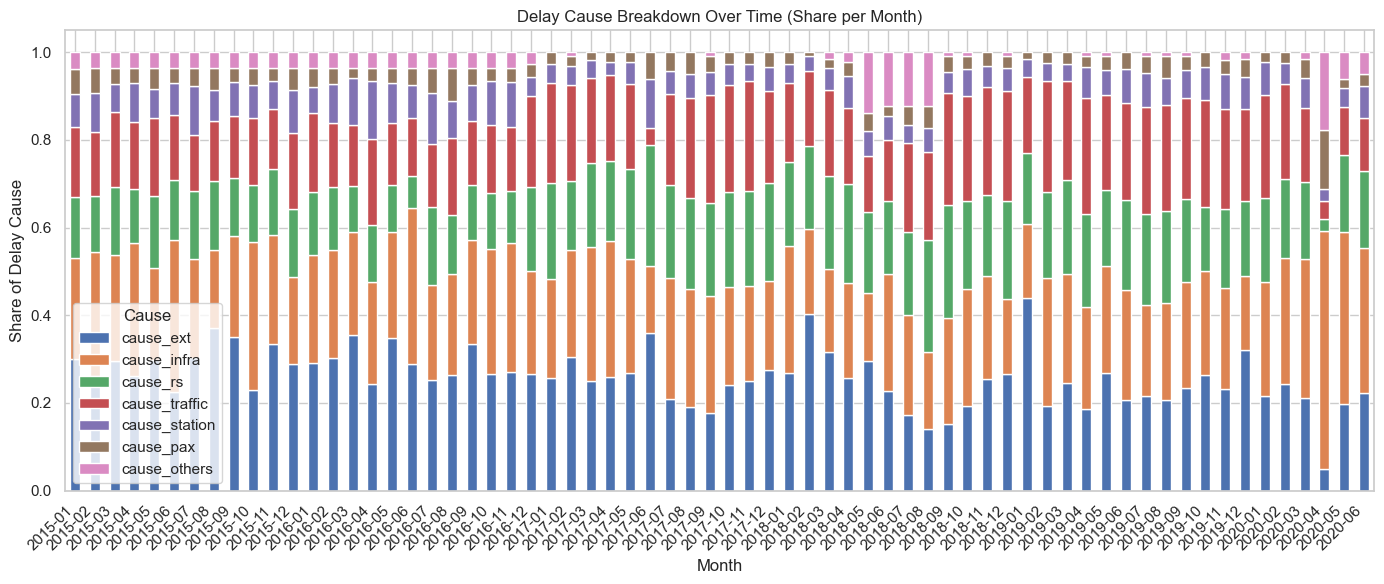

In [102]:
# Check for seasonality in terms of delay causes 
cause_cols = ["cause_ext", "cause_infra", "cause_rs", "cause_traffic", "cause_station", "cause_pax", "cause_others"]

monthly_causes = (
    df.groupby(pd.Grouper(key="period", freq="MS"))[cause_cols]
      .mean()
      .reset_index()
)

monthly_share = monthly_causes.copy()
monthly_share[cause_cols] = monthly_share[cause_cols].div(
    monthly_share[cause_cols].sum(axis=1),
    axis=0
)

monthly_share_bar = monthly_share.set_index("period")[cause_cols]
monthly_share_bar.index = monthly_share_bar.index.strftime("%Y-%m")  # format labels

ax = monthly_share_bar.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

ax.set_title("Delay Cause Breakdown Over Time (Share per Month)")
ax.set_xlabel("Month")
ax.set_ylabel("Share of Delay Cause")
ax.legend(title="Cause")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation**: No specific correlation, spread seems regular and random with no huge fluctuations. 

#### _Step 8: Multivariate Analysis: Route-based_

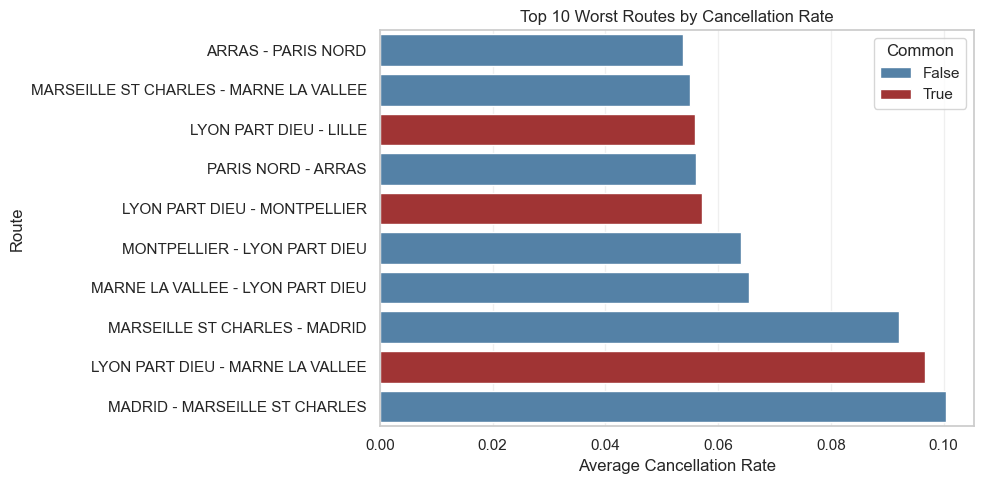

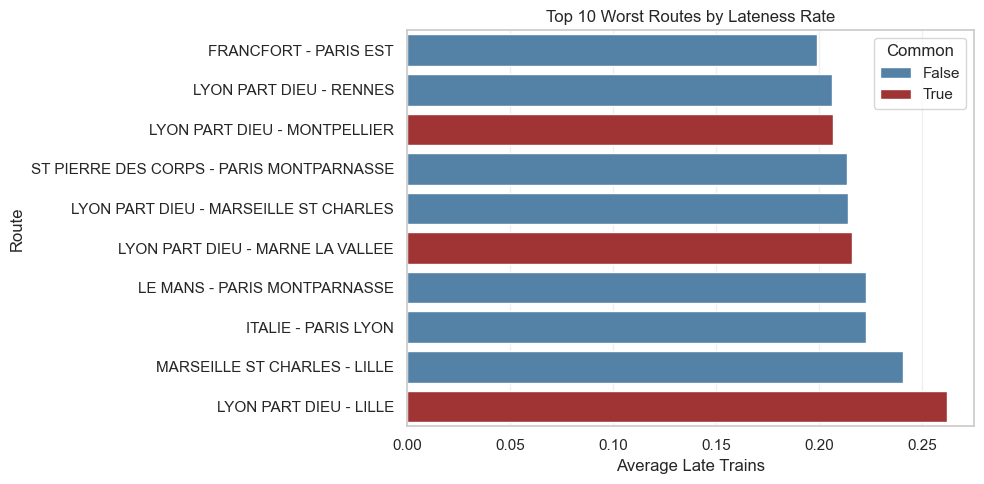

In [110]:
common_routes = set(top10_cancel["liaison"]) & set(top10_late["liaison"])
top10_cancel["Common"] = top10_cancel["liaison"].isin(common_routes)
top10_late["Common"] = top10_late["liaison"].isin(common_routes)
palette = {True: "firebrick", False: "steelblue"}

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_cancel.sort_values("cancellation_rate"),
    y="liaison",
    x="cancellation_rate",
    hue="Common",
    palette=palette,
    dodge=False
)

plt.title("Top 10 Worst Routes by Cancellation Rate")
plt.xlabel("Average Cancellation Rate")
plt.ylabel("Route")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_late.sort_values("lateness_rate"),
    y="liaison",
    x="lateness_rate",
    hue="Common",
    palette=palette,
    dodge=False
)

plt.title("Top 10 Worst Routes by Lateness Rate")
plt.xlabel("Average Late Trains")
plt.ylabel("Route")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation**: The 3 common routes across cancellation rate and high lateness rate all originate from Lyon Part Dieu. 

<Axes: xlabel='avg_travel_time', ylabel='avg_delay_all_trains'>

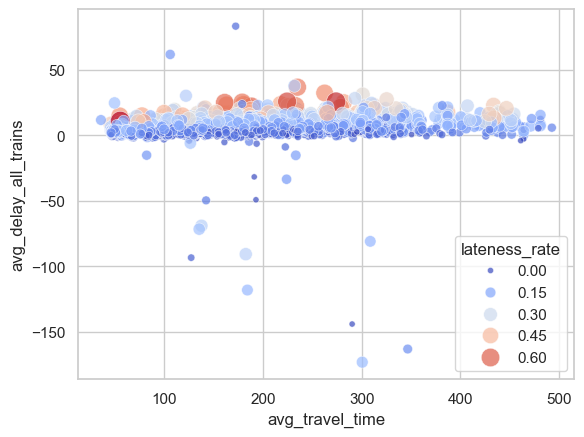

In [111]:
# check if route length has anything to do with delays

sns.scatterplot(
    data=df,
    x='avg_travel_time',
    y='avg_delay_all_trains',
    hue='lateness_rate',
    size='lateness_rate',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.7
)



**Observation**: There appears to be a few anomalies which are skewing the data. Remove these anomalies and view the plot again.  


In [121]:
# drop the singular anomaly where all trains were late 
# for the route of BORDEAUX ST JEAN	-> TOURCOING
df = df[df['lateness_rate'] != 1]
df = df[df['avg_delay_all_trains'] >= -20]

<Axes: xlabel='avg_travel_time', ylabel='avg_delay_all_trains'>

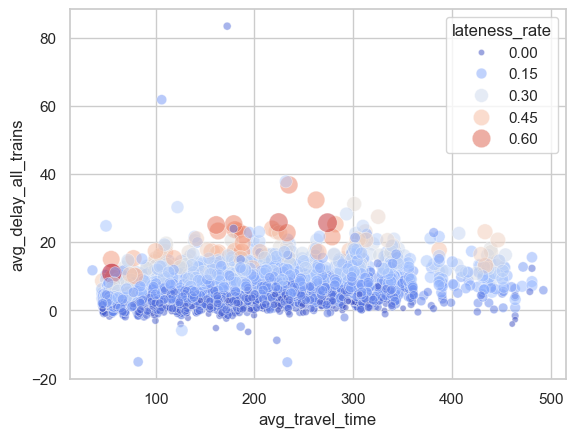

In [122]:
sns.scatterplot(
    data=df,
    x='avg_travel_time',
    y='avg_delay_all_trains',
    hue='lateness_rate',
    size='lateness_rate',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.5
)


**Observations**: Most routes run very close to schedule (dense horizontal band at 0-15minutes)regardless of its route length. The system is generally on time. 

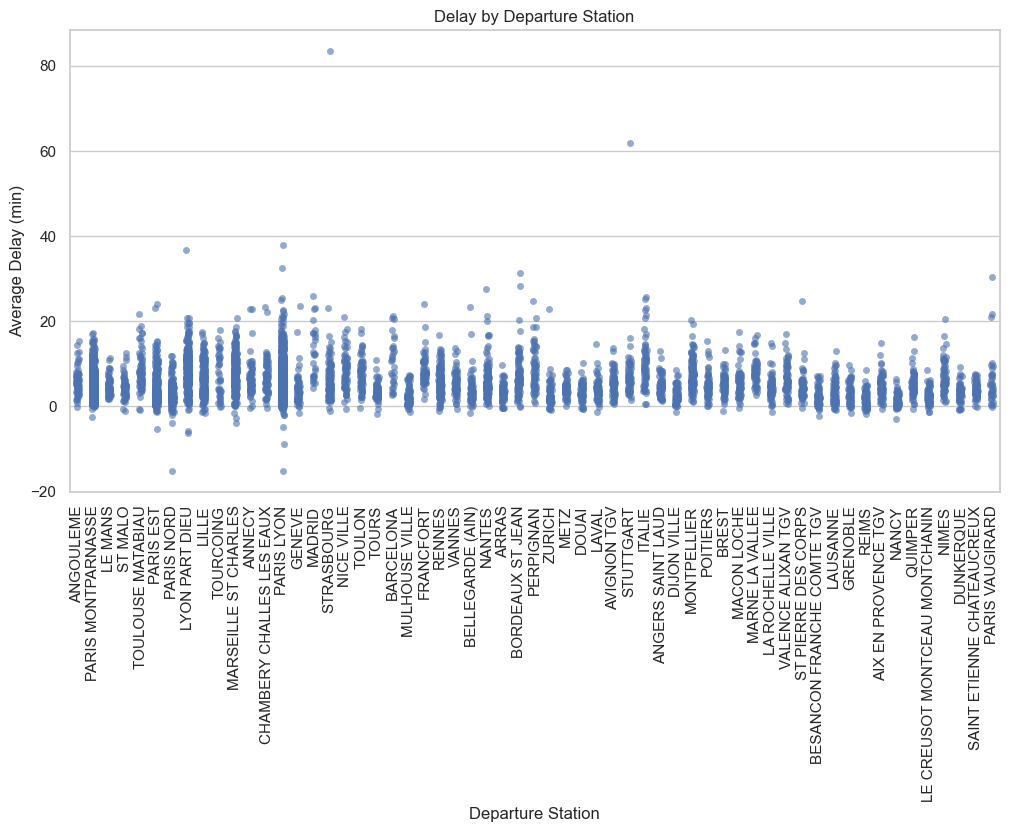

In [124]:
# check out relationship between departure station and delay patterns 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
sns.stripplot(
    data=df,
    x='departure_station',
    y='avg_delay_all_trains',
    jitter=True,
    alpha=0.6
)

plt.title('Delay by Departure Station')
plt.xlabel('Departure Station')
plt.ylabel('Average Delay (min)')
plt.xticks(rotation=90)
plt.show()


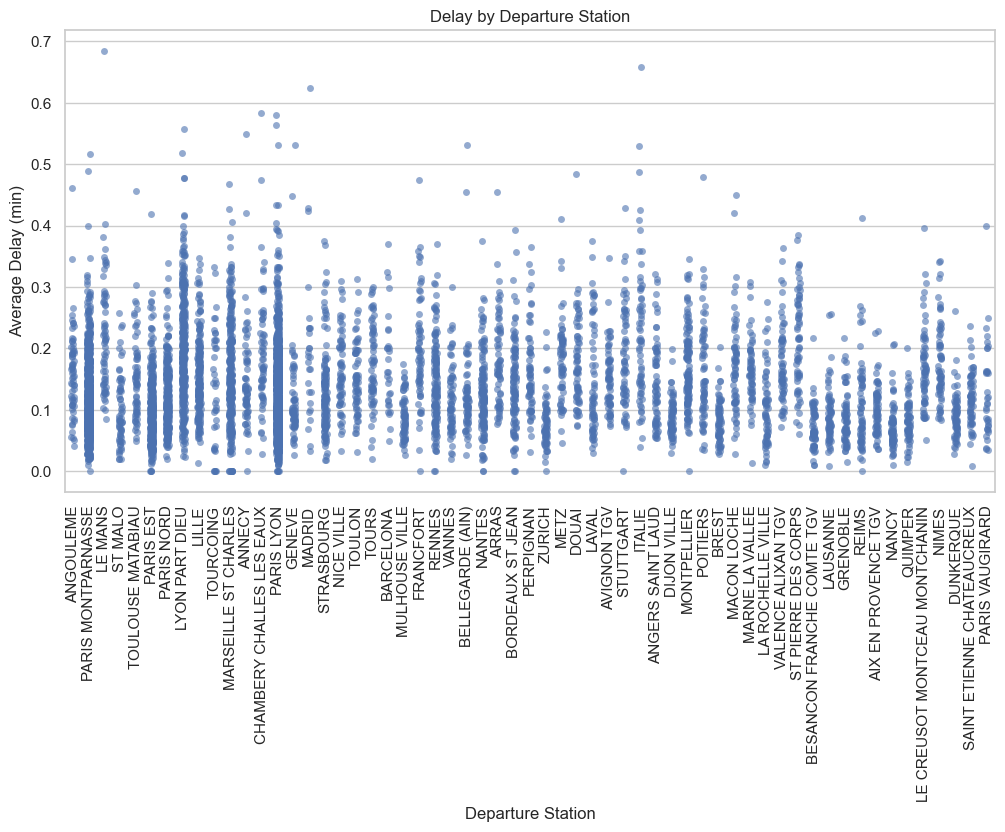

In [125]:
# plot against delay rate instead, for a normalised view 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
sns.stripplot(
    data=df,
    x='departure_station',
    y='lateness_rate',
    jitter=True,
    alpha=0.6
)

plt.title('Delay by Departure Station')
plt.xlabel('Departure Station')
plt.ylabel('Average Delay (min)')
plt.xticks(rotation=90)
plt.show()

In [116]:
# Check reliability / volatility of service from that station 
# Based on the variance of the delay timings - i.e how unpredictable delays are
df.groupby('departure_station')['avg_delay_all_late_trains'] \
  .std().sort_values(ascending=False).head(10)


departure_station
NANTES                  25.579758
TOURCOING               25.091219
MADRID                  24.777767
LA ROCHELLE VILLE       20.752380
PARIS VAUGIRARD         20.713702
BARCELONA               20.457857
ST MALO                 18.873054
MARSEILLE ST CHARLES    17.337872
BORDEAUX ST JEAN        15.745743
RENNES                  15.697940
Name: avg_delay_all_late_trains, dtype: float64

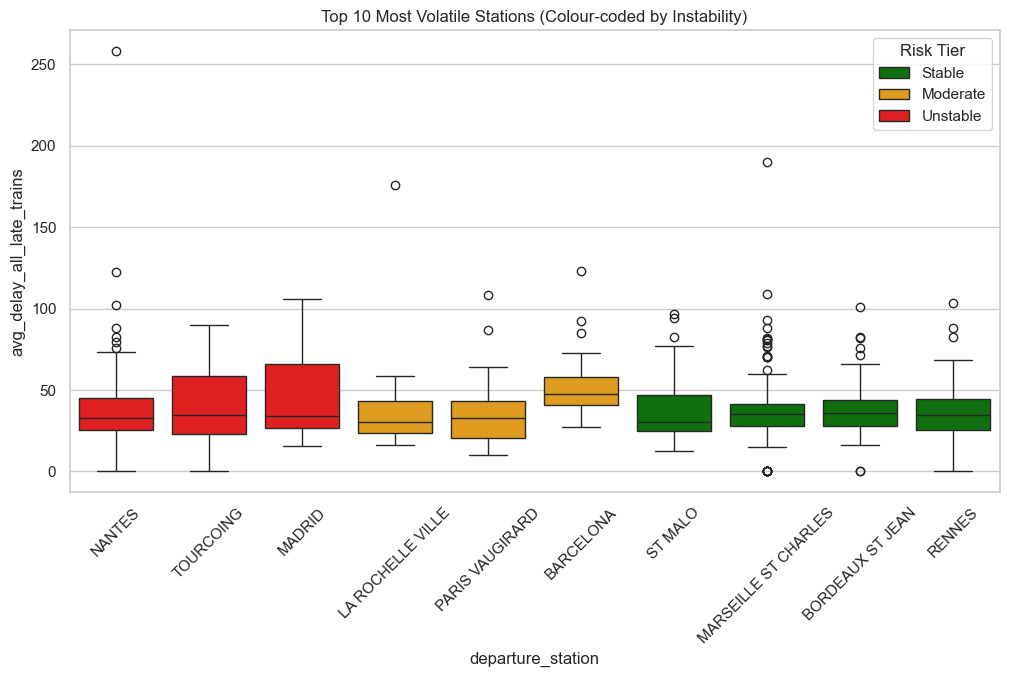

In [126]:
# Do a boxplot of the top most unrealiable stations 

vol = df.groupby('departure_station')['avg_delay_all_late_trains'].std()
top10 = vol.sort_values(ascending=False).head(10).index

segment_map = pd.qcut(vol.loc[top10], q=3, labels=['Stable', 'Moderate', 'Unstable'])
df['Segment'] = df['departure_station'].map(segment_map)

top10_df = df[df['departure_station'].isin(top10)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(
    data=top10_df,
    x='departure_station',
    y='avg_delay_all_late_trains',
    order=top10,   # use Top-10 order
    hue='Segment',
    palette={'Stable':'green', 'Moderate':'orange', 'Unstable':'red'}
)

plt.xticks(rotation=45)
plt.title("Top 10 Most Volatile Stations (Colour-coded by Instability)")
plt.legend(title='Risk Tier')
plt.show()

**Observation**: This a very informative plot. Coupled together with the scatterplot above, some stations are visibly more stable.Instability does not necessarily mean highest average delay. For example, NANTES does not have the highest median, but when things go wrong (such as the 250min delay average), they go very wrong - which translates to unpredictability for the commuter. 

Based on the three tiers of unpredictability / reliability for various stations, the operator's intervention could be segmented into:

- unstable: incident response review, contingency planning, root cause investigation,  
- moderate: e.g. barcelona, these stations while more stable, are consistenlly poor performing, and may point to structural/systemic issues. 

## B. Modeling

#### _Step 8: Data Preprocessing_

The most simple model that we can build is a regression model to estimate the overall average delay time of the route, to predict this route's reliability. 

In [127]:
# drop departure station and arrival station and keep liaison only
df = df.drop(columns=['departure_station', 'arrival_station'])  

In [128]:
# create meaningful time features for modelling 
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['t'] = (df['period'] - df['period'].min()).dt.days
df = df.drop(columns=['period'])

In [136]:
# drop earlier feature created for plotting purposes 
df = df.drop(columns=['Segment'])  

In [138]:
# encode most common routes
top = df['liaison'].value_counts().head(20).index
df['liaison_reduced'] = df['liaison'].where(df['liaison'].isin(top), 'other')
df = pd.get_dummies(df, columns=['liaison_reduced'], drop_first=True)
df.drop(columns=['liaison'], inplace=True)


In [162]:
# define a new target feature to mark a route as high risk if
# it has abnormally high rates of lateness or cancellations 
# it has chronic delays over 60 min > 90% of its cohort or 
# high delay quantum more than 99% percentile of its cohort 
df['high_risk'] = (
    (df['cancellation_rate'] > 0.15) |
    (df['lateness_rate'] > df['lateness_rate'].quantile(0.99)) |
    (df['late_trains_over_60min'] > 10) |
    (df['avg_delay_all_late_trains'] > df['avg_delay_all_late_trains'].quantile(0.99))
).astype(int)


In [163]:
df[df['high_risk']==1]

,year,month,avg_travel_time,expected_trains,cancelled_trains,late_trains,avg_delay_all_late_trains,avg_delay_all_trains,late_trains_over_15min,avg_delay_over_15min,...,liaison_reduced_PARIS LYON - MACON LOCHE,liaison_reduced_PARIS LYON - MULHOUSE VILLE,liaison_reduced_PARIS MONTPARNASSE - BREST,liaison_reduced_PARIS MONTPARNASSE - RENNES,liaison_reduced_PARIS NORD - ARRAS,liaison_reduced_POITIERS - PARIS MONTPARNASSE,liaison_reduced_RENNES - PARIS MONTPARNASSE,liaison_reduced_VANNES - PARIS MONTPARNASSE,liaison_reduced_other,high_risk
7,2019,7.0,85.399381,323.0,0.0,52.0,37.144872,5.523633,28.0,60.874405,...,False,False,False,False,False,False,False,False,True,1
10,2019,7.0,187.298643,287.0,66.0,94.0,31.201064,15.283786,81.0,34.342593,...,False,False,False,False,False,False,False,False,True,1
11,2019,7.0,300.848780,205.0,0.0,45.0,48.023333,13.386179,45.0,48.023333,...,False,False,False,False,False,False,False,False,True,1
13,2019,7.0,109.587302,318.0,66.0,86.0,25.939729,9.933664,60.0,31.826111,...,False,False,False,False,False,False,False,False,True,1
15,2019,7.0,231.904412,180.0,44.0,11.0,36.422727,4.003431,11.0,36.422727,...,False,False,False,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,2020,5.0,46.180556,87.0,15.0,1.0,20.650000,0.426852,1.0,20.650000,...,False,False,False,False,False,False,False,False,True,1
7796,2020,5.0,46.197368,98.0,22.0,11.0,8.118182,2.020175,1.0,15.066667,...,False,False,False,False,False,False,False,False,True,1
7797,2020,5.0,75.809524,33.0,12.0,4.0,7.016667,1.111905,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,1
7799,2020,5.0,193.436620,87.0,16.0,4.0,21.483333,3.508451,5.0,36.320833,...,False,False,False,False,False,False,False,False,True,1


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7726 entries, 0 to 7805
Data columns (total 44 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   year                                                   7726 non-null   int64  
 1   month                                                  7726 non-null   float64
 2   avg_travel_time                                        7726 non-null   float64
 3   expected_trains                                        7726 non-null   float64
 4   cancelled_trains                                       7726 non-null   float64
 5   late_trains                                            7726 non-null   float64
 6   avg_delay_all_late_trains                              7726 non-null   float64
 7   avg_delay_all_trains                                   7726 non-null   float64
 8   late_trains_over_15min                               

#### _Step 9: Baseline Model_

**Recap**: We want to build a simple model to understand the "what, when, why" typical behavioural patterns of a particular route, to advise the train operator pre-emptively, what to look out for on a particular day in order to maintain high service reliability. 

To do so, we first create a new target feature "high risk" to mark out, based on operational requirements, what constitutes a high risk route. Then, we build a model to map any new route-month pair into the model, to create a prioritisation list of high risk routes for the Operator to focus on that month. 

In [189]:
# create a safe features set to train only on data that we would know 
# at the point of prediction 
safe_features = [
    'year', 'month', 'month_sin', 'month_cos',
    'expected_trains', 'avg_travel_time'
] + [c for c in df.columns if c.startswith("liaison_reduced_")]

# create lag features 
# lag_cols = [
#     'late_trains',
#     'cancelled_trains',
#     'avg_delay_all_trains',
#     'late_trains_over_15min',
#     'late_trains_over_30min',
#     'late_trains_over_60min'
# ]
# df = df.sort_values(['liaison', 'year', 'month'])

# for col in lag_cols:
#     df[f'{col}_lag1'] = df.groupby('liaison')[col].shift(1)
#     df[f'{col}_roll3'] = df.groupby('liaison')[col].rolling(3).mean().shift(1)

# df = df.dropna()

X = df[safe_features]
y = df['high_risk']


In [190]:
# split dataset chronologically to prevent data leakage
train = df[df['year'] <= 2018].copy()
test  = df[df['year'] > 2018].copy()

X_train = train[safe_features]
y_train = train['high_risk']

X_test = test[safe_features]
y_test = test['high_risk']

In [191]:
# define a basic baseline model that always predicts the majority class (low risk)
# the outcome of this on the test set will give us an accuracy of 80.9% 
# our advanced models must perform better than 80.9% 
baseline_pred = np.zeros_like(y_test)
baseline_acc = (baseline_pred == y_test).mean()
baseline_acc

0.8085007006071929

#### _Step 10: Logistic Regression_

In [192]:
# fit the model 
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [193]:
# Predict
y_pred = lr.predict(X_test)

# Measure accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification summary
print(classification_report(y_test, y_pred))


Accuracy: 0.6118636151331154
              precision    recall  f1-score   support

           0       0.81      0.68      0.74      1731
           1       0.19      0.32      0.24       410

    accuracy                           0.61      2141
   macro avg       0.50      0.50      0.49      2141
weighted avg       0.69      0.61      0.64      2141



**Observation**: Our logistic regression model performed worse off than our dumb model!

In [197]:
# Probability that each test sample is "high risk"
y_prob = lr.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Predicted risk rate:", y_pred.mean())


Confusion matrix:
 [[1180  551]
 [ 280  130]]
ROC AUC: 0.519202209353116
Predicted risk rate: 0.31807566557683326


**Observation**: Our model is too weak, with an ROC of 52% it is basically guessing. We may need to add in some stronger features. That said, having a more conservative prediction may not be a bad thing in the preventive context - it allows for some level of precaution in our early interventions. 

In [ ]:
importance = pd.Series(lr.coef_[0], index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))


liaison_reduced_LYON PART DIEU - MARSEILLE ST CHARLES    2.295543
liaison_reduced_AVIGNON TGV - PARIS LYON                 0.952868
liaison_reduced_MARSEILLE ST CHARLES - LYON PART DIEU    0.759824
month_sin                                                0.590944
liaison_reduced_MACON LOCHE - PARIS LYON                 0.456137
liaison_reduced_POITIERS - PARIS MONTPARNASSE            0.252699
liaison_reduced_PARIS LYON - MACON LOCHE                 0.228744
liaison_reduced_ANGOULEME - PARIS MONTPARNASSE           0.222629
liaison_reduced_RENNES - PARIS MONTPARNASSE              0.188031
month                                                    0.120353
dtype: float64
